In [1]:
%matplotlib inline

# Predicted Population Counts

* **Input**: cleaned and optimized pickeled DataFrames (persons.csv), BFS population predictions
* **Output**: Visualisations

**BFS data:**
* Kantonale Bevölkerungsszenarien 2015-2045
* By default: "Referenzszenario AR-00-2015"

In [2]:
import logging
import math
import os
import sys
import geopandas as gpd
import pandas as pd

from matplotlib import pyplot as plt

In [3]:
sys.path.append(r'X:\90_Persoenlich\u229285\dev\SynPopToolbox')

In [4]:
from synpop.marginals import FSO_PopPredictionsClient
from synpop.visualisations import SwissZoneMap
import synpop.utils as utils

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Settings" data-toc-modified-id="Settings-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Settings</a></span></li><li><span><a href="#Loading-Data" data-toc-modified-id="Loading-Data-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Loading Data</a></span><ul class="toc-item"><li><span><a href="#SynPop" data-toc-modified-id="SynPop-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>SynPop</a></span></li><li><span><a href="#BFS-Data" data-toc-modified-id="BFS-Data-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>BFS-Data</a></span></li></ul></li><li><span><a href="#Total-Population" data-toc-modified-id="Total-Population-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Total Population</a></span><ul class="toc-item"><li><span><a href="#Whole-of-Switerland" data-toc-modified-id="Whole-of-Switerland-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Whole of Switerland</a></span></li><li><span><a href="#By-Canton" data-toc-modified-id="By-Canton-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>By Canton</a></span></li><li><span><a href="#Zonal-Analysis" data-toc-modified-id="Zonal-Analysis-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Zonal Analysis</a></span></li></ul></li><li><span><a href="#Export-Notebook-to-HTML" data-toc-modified-id="Export-Notebook-to-HTML-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Export Notebook to HTML</a></span></li></ul></div>

##  Settings

In [5]:
YEAR_IST = 2017
YEAR = 2030

DATA_DIR_IST = r'\\k13536\mobi\10_Daten\SynPop\2017\190813_CH_2017_BEST1\02_preprocessed'
SYNPOP_PERSONS_FILE_IST = os.path.join(DATA_DIR_IST, 'persons_{}.pickle.gzip'.format(YEAR_IST))

DATA_DIR = r'\\k13536\mobi\10_Daten\SynPop\2030\02_preprocessed'
SYNPOP_PERSONS_FILE = os.path.join(DATA_DIR, 'persons_{}.pickle.gzip'.format(YEAR))

**Plot Export Settings**

In [6]:
SAVE_FIGURES = True
OUTPUT_DIR = './outputs'
FIG_FORMAT = 'png'
FIG_DPI = 150
FIG_BBOX_INCHES = 'tight'
FIG_PAD_INCHES = 0.2

In [7]:
utils.create_dir(OUTPUT_DIR)

2020-02-18 09:58:51,287 - INFO - synpop.utils: "./outputs" exists already


## Loading Data

### SynPop

**Scenario Year**

In [8]:
SYNPOP_PERSONS_FILE

'\\\\k13536\\mobi\\10_Daten\\SynPop\\2030\\02_preprocessed\\persons_2030.pickle.gzip'

In [9]:
%%time
persons = pd.read_pickle(SYNPOP_PERSONS_FILE, compression='gzip') 

Wall time: 14.7 s


In [10]:
persons.shape

(9557232, 33)

**IST**

In [11]:
SYNPOP_PERSONS_FILE_IST

'\\\\k13536\\mobi\\10_Daten\\SynPop\\2017\\190813_CH_2017_BEST1\\02_preprocessed\\persons_2017.pickle.gzip'

In [12]:
%time
persons_ist = pd.read_pickle(SYNPOP_PERSONS_FILE_IST, compression='gzip')

Wall time: 0 ns


In [13]:
persons_ist.shape

(8560151, 33)

### BFS-Data

In [14]:
%%time
bfs_pop_pred = FSO_PopPredictionsClient().load(year=YEAR)

Wall time: 7.24 s


# Analysis

## Total Population

### Whole of Switerland

In [15]:
print('Global population BFS (only permanent residents): {}'.format(bfs_pop_pred.pop_total))
print('Global population SynPop: {}'.format(len(persons)))

delta = len(persons) - bfs_pop_pred.pop_total
print('Delta: {:.0f} ({:.1f}%)'.format(delta, delta / bfs_pop_pred.pop_total * 100))

Global population BFS (only permanent residents): 9467377
Global population SynPop: 9557232
Delta: 89855 (0.9%)


### By Canton

In [16]:
synpop_by_canton = persons.groupby('KT_full')['person_id'].count().rename('SynPop_pop')

In [17]:
bfs_pop = bfs_pop_pred.pop_by_canton.set_index('KT_full')['pop'].rename('BFS_pop')

In [18]:
pop_by_canton = pd.concat([bfs_pop, synpop_by_canton], axis=1, sort=False)
pop_by_canton['delta_abs'] = (pop_by_canton['SynPop_pop'] - pop_by_canton['BFS_pop'])
pop_by_canton['delta_pc'] = (pop_by_canton['delta_abs'] / pop_by_canton['BFS_pop'] * 100).round(1)

2020-02-18 09:59:31,135 - INFO - numexpr.utils: NumExpr defaulting to 8 threads.


In [19]:
pop_by_canton

,BFS_pop,SynPop_pop,delta_abs,delta_pc
KT_full,,,,
Aargau,759240,778640,19400,2.6
Appenzell Ausserrhoden,57581,52631,-4950,-8.6
Appenzell Innerrhoden,16244,15242,-1002,-6.2
Basel-Landschaft,302771,308798,6027,2.0
Basel-Stadt,204394,186926,-17468,-8.5
Bern / Berne,1116845,1159494,42649,3.8
Fribourg / Freiburg,381573,388609,7036,1.8
Genève,556506,546898,-9608,-1.7
Glarus,43264,40311,-2953,-6.8


**Visualisations**

In [20]:
default_map_client = SwissZoneMap(outline_cantons=True)

In [21]:
def round_up(x):
    return int(math.ceil(x / 1000.0)) * 1000

2020-02-18 09:59:32,111 - INFO - root: Figure saved to file : ./outputs\01-01_SynPop2030_vs_BFS_absolute_pop_diff.png


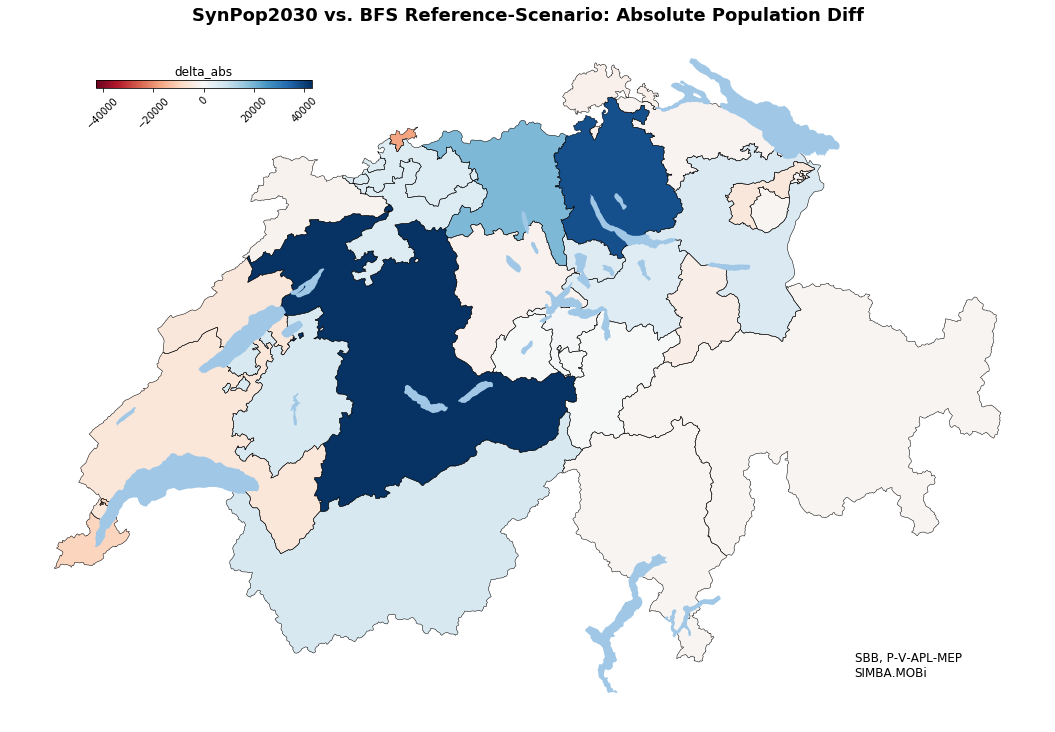

In [22]:
title = 'SynPop{} vs. BFS Reference-Scenario: Absolute Population Diff'.format(YEAR)
scale_bound = round_up(pop_by_canton['delta_abs'].abs().max())
ax = default_map_client.draw_cantons(pop_by_canton, 'delta_abs', vmin=-scale_bound, vmax=scale_bound, title=title)

if SAVE_FIGURES:
    fig_file_name = '01-01_SynPop{}_vs_BFS_absolute_pop_diff.{}'.format(YEAR, FIG_FORMAT)
    fig_file_path = os.path.join(OUTPUT_DIR, fig_file_name)
    plt.savefig(fig_file_path, dpi=FIG_DPI,  format=FIG_FORMAT, bbox_inches=FIG_BBOX_INCHES, pad_inches=FIG_PAD_INCHES)
    logging.info('Figure saved to file : {}'.format(fig_file_path))

2020-02-18 09:59:33,192 - INFO - root: Figure saved to file : ./outputs\01-02_SynPop2030_vs_BFS_pct_pop_diff.png


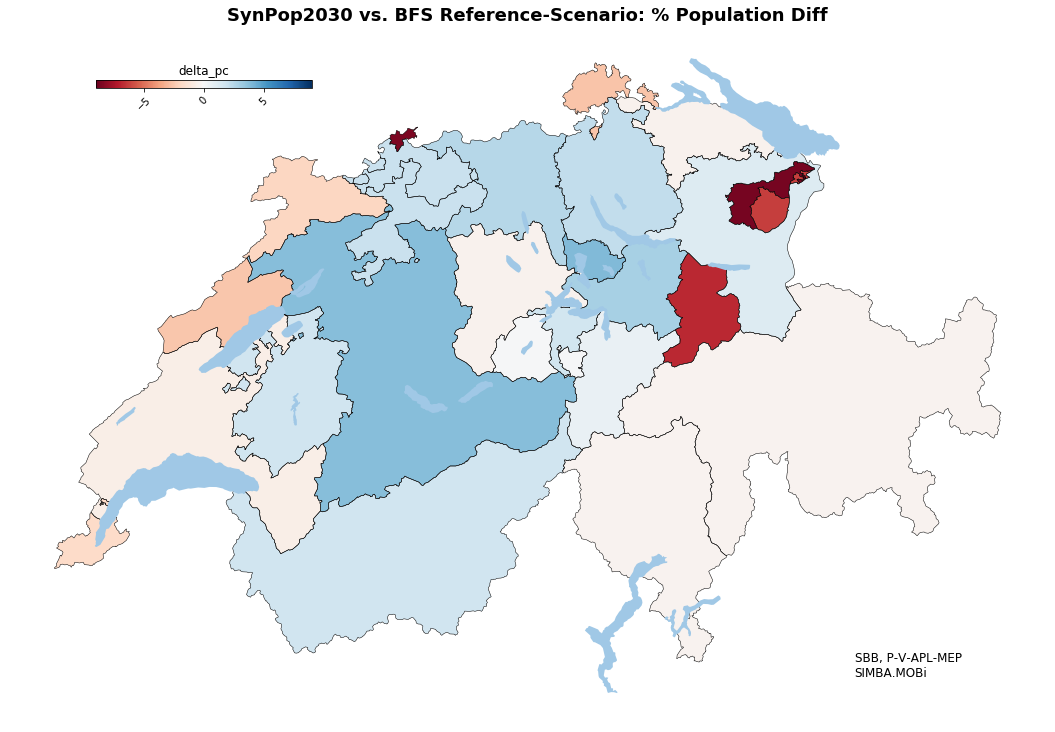

In [23]:
title = 'SynPop{} vs. BFS Reference-Scenario: % Population Diff'.format(YEAR)
scale_bound = round(pop_by_canton['delta_pc'].abs().max())
ax = default_map_client.draw_cantons(pop_by_canton, 'delta_pc', vmin=-scale_bound, vmax=scale_bound, title=title)

if SAVE_FIGURES:
    fig_file_name = '01-02_SynPop{}_vs_BFS_pct_pop_diff.{}'.format(YEAR, FIG_FORMAT)
    fig_file_path = os.path.join(OUTPUT_DIR, fig_file_name)
    plt.savefig(fig_file_path, dpi=FIG_DPI,  format=FIG_FORMAT, bbox_inches=FIG_BBOX_INCHES, pad_inches=FIG_PAD_INCHES)
    logging.info('Figure saved to file : {}'.format(fig_file_path))

### Zonal Analysis

In [24]:
%%time
zonal_stats = (pd.concat([persons_ist.groupby('location_id').count().iloc[:, 0].rename(f'pop {YEAR_IST}'),
                          persons.groupby('location_id').count().iloc[:, 0].rename(f'pop {YEAR}')
                          ], axis=1, join='outer')
                .fillna(0)
                .astype(int)
                )

Wall time: 28.3 s


In [25]:
zonal_stats

,pop 2017,pop 2030
location_id,,
101001,1949,2418
201001,1235,1514
201002,409,510
201003,1309,1391
201004,1199,1680
...,...,...
681001001,424,366
681001002,152,119
681001003,185,163


In [26]:
%%time
zone_to_commune = (pd.concat([persons[['location_id', 'N_Gem']], persons_ist[['location_id', 'N_Gem']]])
                   .drop_duplicates()
                   .set_index('location_id').iloc[:, 0]
                   .to_dict()
                   )
zonal_stats['N_Gem'] = zonal_stats.index.map(zone_to_commune).values

zone_to_canton = (pd.concat([persons[['location_id', 'N_KT']], persons_ist[['location_id', 'N_KT']]])
                   .drop_duplicates()
                   .set_index('location_id').iloc[:, 0]
                   .to_dict()
                   )
zonal_stats['N_KT'] = zonal_stats.index.map(zone_to_canton).values


Wall time: 9.72 s


In [27]:
zonal_stats['growth abs'] = zonal_stats[f'pop {YEAR}'] - zonal_stats[f'pop {YEAR_IST}']
zonal_stats['growth factor'] = zonal_stats[f'pop {YEAR}'] / zonal_stats[f'pop {YEAR_IST}']

zonal_stats = zonal_stats[[f'pop {YEAR_IST}', f'pop {YEAR}', 'growth abs', 'growth factor', 'N_Gem', 'N_KT']]

In [28]:
zonal_stats

,pop 2017,pop 2030,growth abs,growth factor,N_Gem,N_KT
location_id,,,,,,
101001,1949,2418,469,1.240636,Aeugst am Albis,ZH
201001,1235,1514,279,1.225911,Affoltern am Albis,ZH
201002,409,510,101,1.246944,Affoltern am Albis,ZH
201003,1309,1391,82,1.062643,Affoltern am Albis,ZH
201004,1199,1680,481,1.401168,Affoltern am Albis,ZH
...,...,...,...,...,...,...
681001001,424,366,-58,0.863208,La Baroche,JU
681001002,152,119,-33,0.782895,La Baroche,JU
681001003,185,163,-22,0.881081,La Baroche,JU


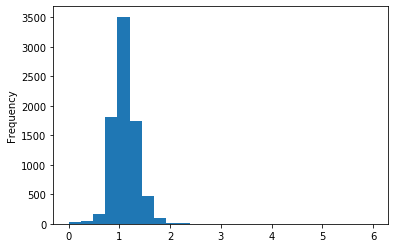

In [29]:
ax = zonal_stats['growth factor'].plot.hist(bins=25)

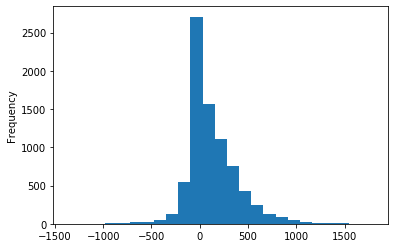

In [30]:
ax = zonal_stats['growth abs'].plot.hist(bins=25)

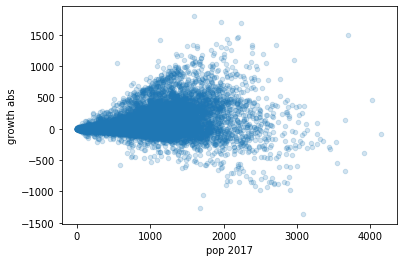

In [31]:
ax= zonal_stats.plot.scatter(x=f'pop {YEAR_IST}', y='growth abs', alpha=0.2)

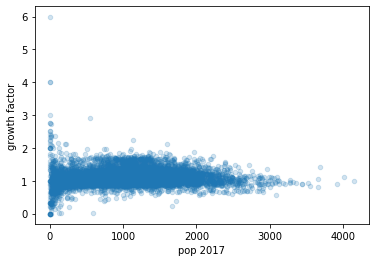

In [32]:
ax = zonal_stats.plot.scatter(x=f'pop {YEAR_IST}', y='growth factor', alpha=0.2)

**Per Canton**

In [33]:
zonal_stats.head().columns

Index(['pop 2017', 'pop 2030', 'growth abs', 'growth factor', 'N_Gem', 'N_KT'], dtype='object')

In [34]:
commune_stats = zonal_stats.groupby('N_Gem').aggregate({f'pop {YEAR_IST}': sum, f'pop {YEAR}': sum, 'growth abs': sum, 
                                                        'N_KT': 'first', 'growth factor': [min, max]
                                                        })

commune_stats.columns = [f'pop {YEAR_IST}', f'pop {YEAR}', 'growth abs', 'N_KT', 'min zgf', 'max zgf']

commune_stats['growth factor'] = commune_stats[f'pop {YEAR}'] / commune_stats['pop 2017']

commune_stats['delta min/max'] = commune_stats['max zgf'] - commune_stats['min zgf']

commune_stats = commune_stats[[f'pop {YEAR_IST}', f'pop {YEAR}', 'growth abs', 'growth factor', 'min zgf', 'max zgf',
                               'delta min/max', 'N_KT']]

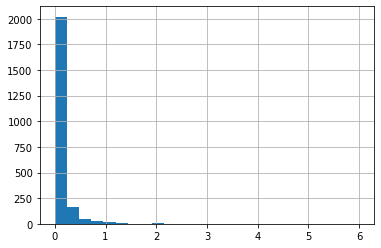

In [35]:
commune_stats['delta min/max'].hist(bins=25)

**Export to Excel**

In [36]:
with pd.ExcelWriter(os.path.join(OUTPUT_DIR, '01_stats_per_zone.xlsx')) as writer:  
    zonal_stats.to_excel(writer, sheet_name='zonal_stats')
    commune_stats.to_excel(writer, sheet_name='commune_stats')

## Export Notebook to HTML

In [38]:
### Write notebook to a html file
!jupyter nbconvert --to html 01_Predicted_Population_Counts.ipynb

[NbConvertApp] Converting notebook 01_Predicted_Population_Counts.ipynb to html
[NbConvertApp] Writing 867950 bytes to 01_Predicted_Population_Counts.html
